# SQL 业务洞察与维修优先级分析

本 notebook 使用 Day19 导出的最终预测结果表，展示模型输出如何转化为维修容量、风险等级、Decile/Lift 和阈值敏感性分析。目标不是重新训练模型，而是把预测概率转化为维修资源分配视角。该 notebook 支撑 README 的 Business Insights 和 Threshold Sensitivity 部分。

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
SQL_EXPORT_DIR = PROJECT_ROOT / 'outputs' / 'sql_exports'
FINAL_TABLE_DIR = PROJECT_ROOT / 'outputs' / 'tables' / 'final'
FINAL_FIGURE_DIR = PROJECT_ROOT / 'outputs' / 'figures' / 'final'

SQL_EXPORT_DIR, FINAL_TABLE_DIR, FINAL_FIGURE_DIR

(WindowsPath('c:/Scania APS/outputs/sql_exports'),
 WindowsPath('c:/Scania APS/outputs/tables/final'),
 WindowsPath('c:/Scania APS/outputs/figures/final'))

## 1. 读取最终业务分析表

本节读取 Day19/Day20 已生成的 SQL exports 和 final tables

In [2]:
model_prediction_results = pd.read_csv(SQL_EXPORT_DIR / 'model_prediction_results.csv')
model_policy_comparison = pd.read_csv(SQL_EXPORT_DIR / 'model_policy_comparison.csv')
threshold_sensitivity_results = pd.read_csv(SQL_EXPORT_DIR / 'threshold_sensitivity_results.csv')

model_prediction_results.shape, model_policy_comparison.shape, threshold_sensitivity_results.shape

((16000, 17), (5, 17), (99, 15))

## 2. Top-K 维修容量：如果只能检查前 K 个高风险样本，能覆盖多少真实故障？

维修团队通常存在检查容量限制，因此需要评估模型排序在 Top-K 场景下的故障覆盖能力。

,top_k,inspected_count,actual_pos_count,total_pos_count,precision_at_k,recall_at_k,missed_pos_count,estimated_workload,estimated_avoided_fn_cost
0,50,50,50,375,1.000,0.133333,325,50,25000
1,100,100,100,375,1.000,0.266667,275,100,50000
2,200,200,194,375,0.970,0.517333,181,200,97000
3,500,500,340,375,0.680,0.906667,35,500,170000
4,1000,1000,369,375,0.369,0.984000,6,1000,184500


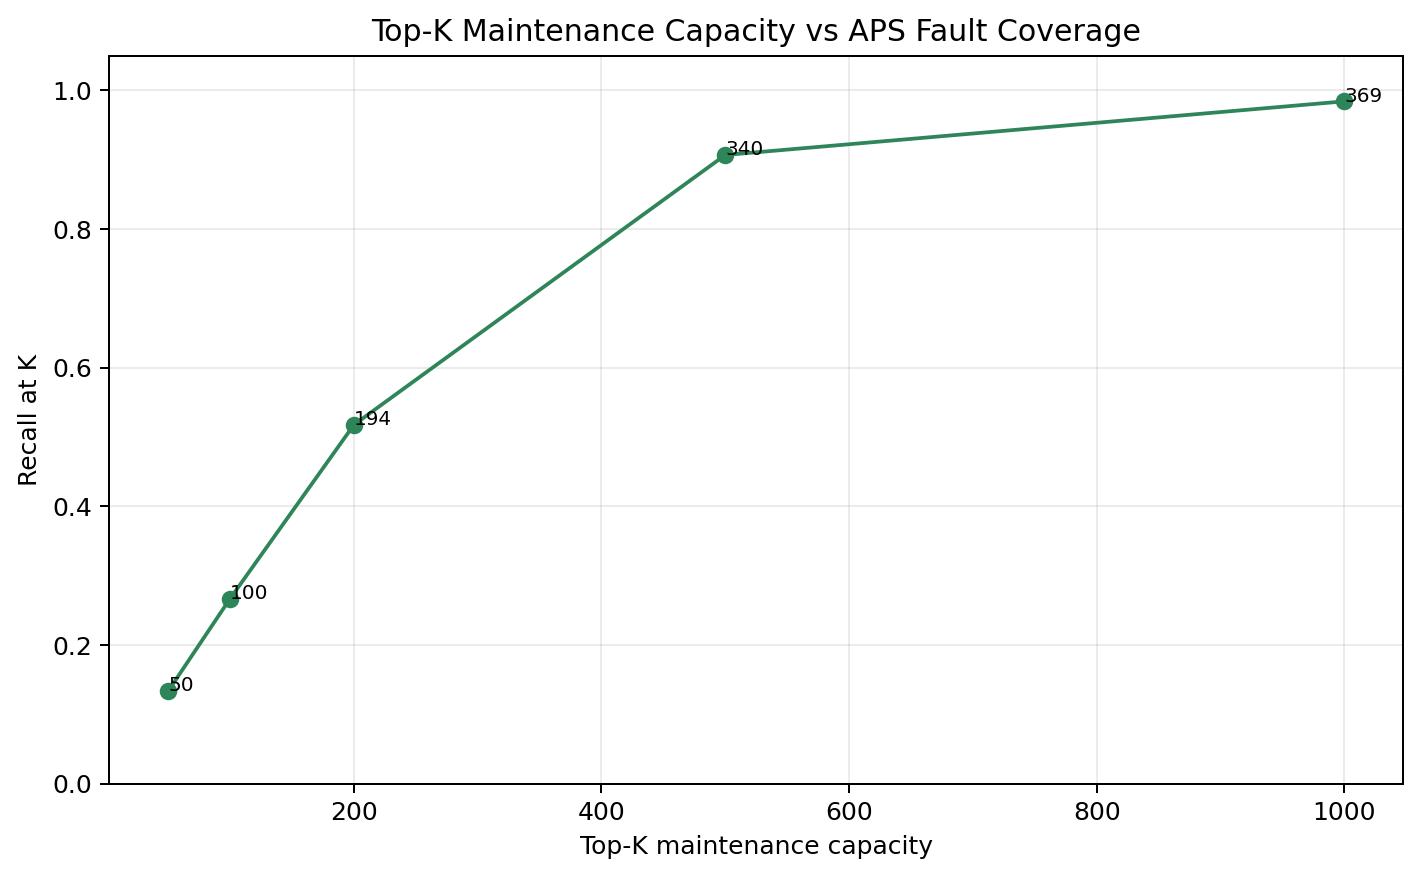

In [3]:
topk = pd.read_csv(FINAL_TABLE_DIR / 'final_topk_maintenance_capacity.csv')
display(topk)
display(Image(filename=str(FINAL_FIGURE_DIR / 'final_topk_maintenance_capacity.png')))

结果显示：Top 50 命中 50 个真实 APS 故障，Top 100 命中 100 个，Top 500 命中 340 / 375 个。该排序结果可用于维修队列优先级规划。

## 3. 风险等级工作量：Critical / High / Medium / Low 各对应多少检查压力？

风险分层用于把连续概率转化成可执行的维修动作，并估计不同风险层级的工作量。

,risk_level,suggested_action,sample_count,actual_pos_count,predicted_pos_count,actual_pos_rate,predicted_pos_rate,avg_predicted_probability,tp_count,fp_count,fn_count,estimated_workload,priority_order
0,Critical,immediate_inspection,404,316,404,0.782178,1.000000,0.962373,316,88,0,404,1
1,High,priority_inspection,321,46,321,0.143302,1.000000,0.454767,46,275,0,321,2
2,Medium,monitor_and_recheck,414,8,36,0.019324,0.086957,0.105079,1,35,7,414,3
3,Low,no_action_now,14861,5,0,0.000336,0.000000,0.003503,0,0,5,14861,4


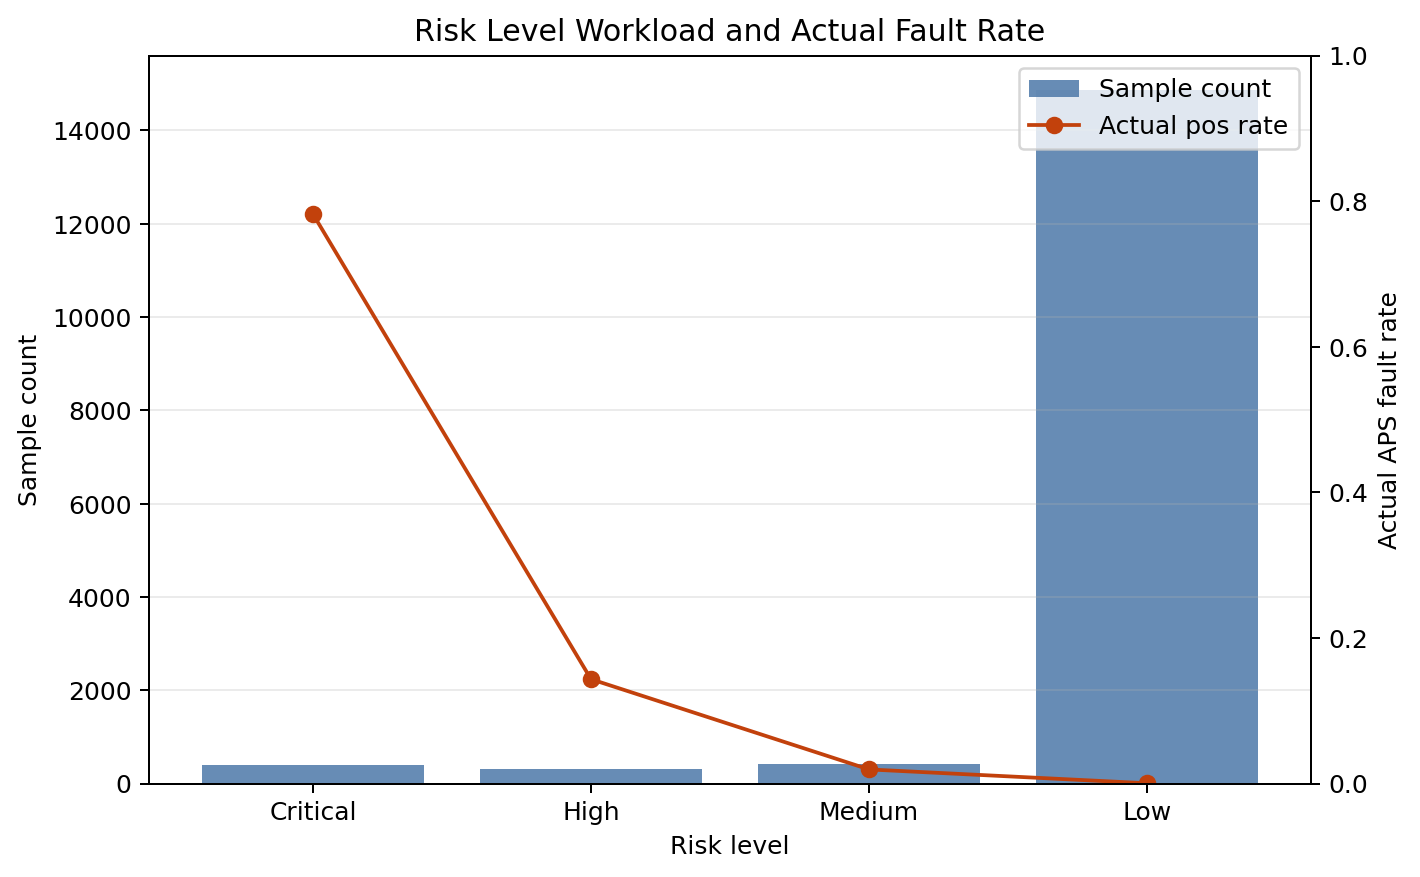

In [4]:
risk_workload = pd.read_csv(FINAL_TABLE_DIR / 'final_risk_workload_summary.csv')
display(risk_workload)
display(Image(filename=str(FINAL_FIGURE_DIR / 'final_risk_level_workload.png')))

结果显示：Critical 层级样本数为 404，真实正类率为 78.22%；High 层级样本数为 321，真实正类率为 14.33%。这支持优先检修 Critical / High 样本，同时也提示 High 层级会带来额外检查工作量。

## 4. 成本策略对比

该表只在 official test policy 内比较成本；`oof_train` 结果保留为稳健性检查记录

,policy_name,dataset,threshold,fp,fn,fp_cost_total,fn_cost_total,total_cost,cost_reduction,cost_reduction_rate,note
0,naive_all_negative,official_test,NaN,0,375,0,187500,187500,0,0.000000,全预测为 neg 的 naive baseline，作为 official test 成本下...
1,day14_baseline_median_all,official_test,0.16,432,13,4320,6500,10820,176680,0.942293,Day14 未调参 baseline_median_all official test 结果。
2,day14_structural_all_final_candidate,official_test,0.18,398,12,3980,6000,9980,177520,0.946773,当前最终推荐候选，使用 Day13 valid 选择的 threshold=0.18。
3,day16_tuned_best,official_test,0.19,376,15,3760,7500,11260,176240,0.939947,Day15 tuned 参数在 Day16 official test 上的最低成本方案，用...
4,day18_oof_ensemble_best,oof_train,0.14,1841,41,18410,20500,38910,461090,0.922180,OOF train 内部口径结果，不可与 official test 成本直接横向比较。


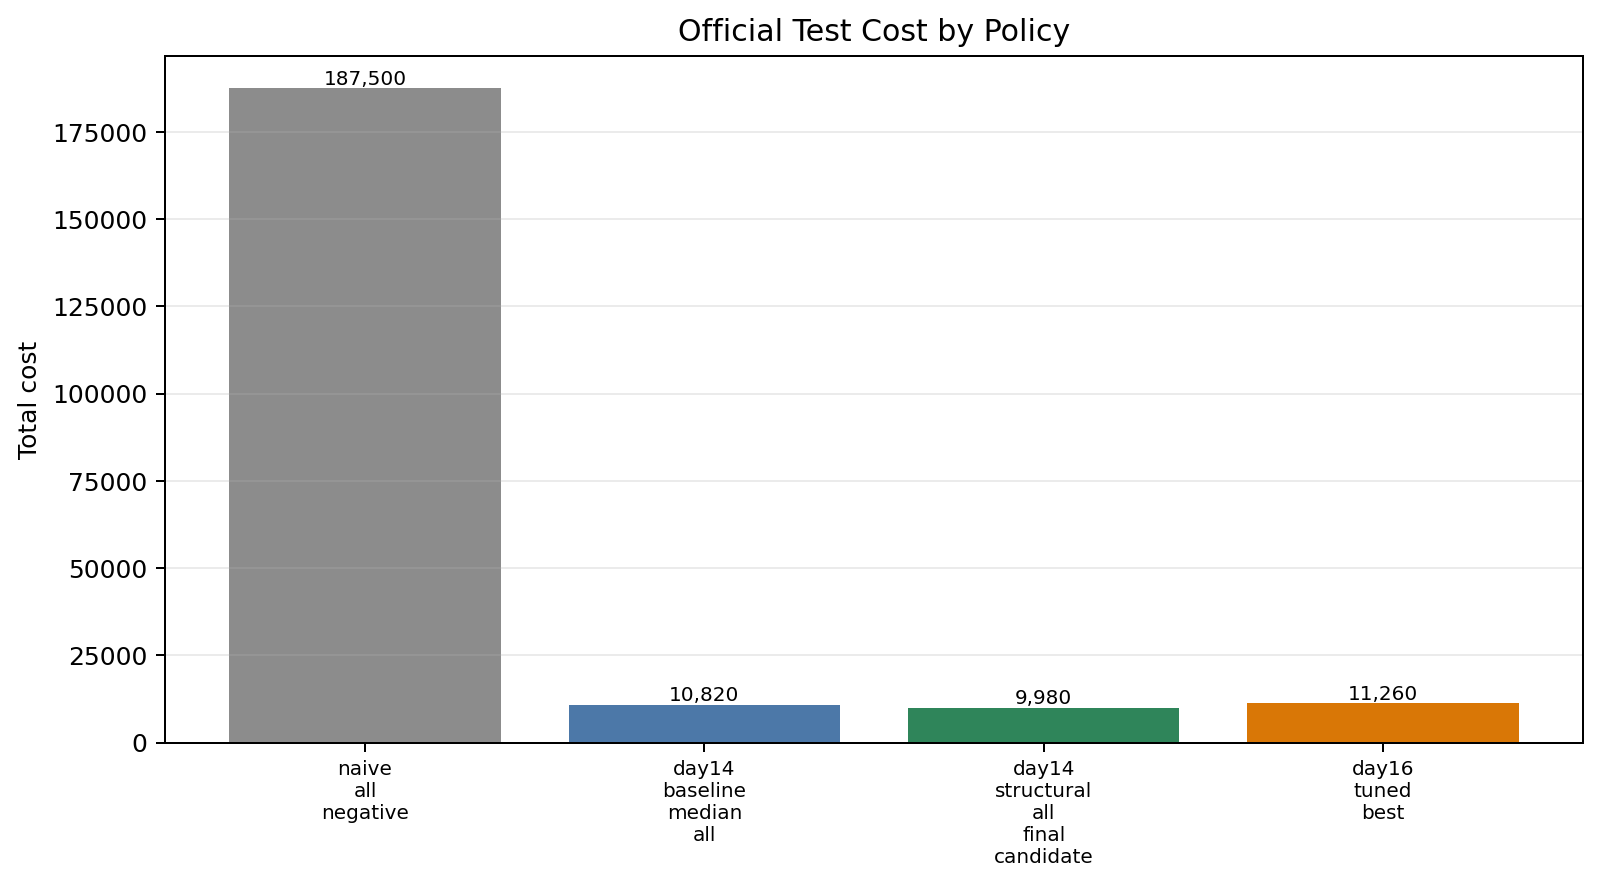

In [5]:
policy_cost = pd.read_csv(FINAL_TABLE_DIR / 'final_policy_cost_comparison.csv')
display(policy_cost)
display(Image(filename=str(FINAL_FIGURE_DIR / 'final_cost_policy_comparison.png')))

成本对比用于复核 README 中的 final result：Day14 structural_all final candidate 的 total_cost 为 `9980`，低于 naive baseline、Day14 baseline 和 Day16 tuned best。

## 5. Decile / Lift：模型排序是否真正集中故障样本？

Decile / Lift 用于检查最高风险分位是否显著集中真实故障。

,decile,sample_count,actual_pos_count,pos_rate,cumulative_sample_count,cumulative_pos_count,cumulative_recall,overall_pos_rate,lift
0,1,1600,373,0.233125,1600,373,0.994667,0.023438,9.946667
1,2,1600,0,0.000000,3200,373,0.994667,0.023438,0.000000
2,3,1600,1,0.000625,4800,374,0.997333,0.023438,0.026667
3,4,1600,0,0.000000,6400,374,0.997333,0.023438,0.000000
4,5,1600,0,0.000000,8000,374,0.997333,0.023438,0.000000
5,6,1600,1,0.000625,9600,375,1.000000,0.023438,0.026667
6,7,1600,0,0.000000,11200,375,1.000000,0.023438,0.000000
7,8,1600,0,0.000000,12800,375,1.000000,0.023438,0.000000
8,9,1600,0,0.000000,14400,375,1.000000,0.023438,0.000000
9,10,1600,0,0.000000,16000,375,1.000000,0.023438,0.000000


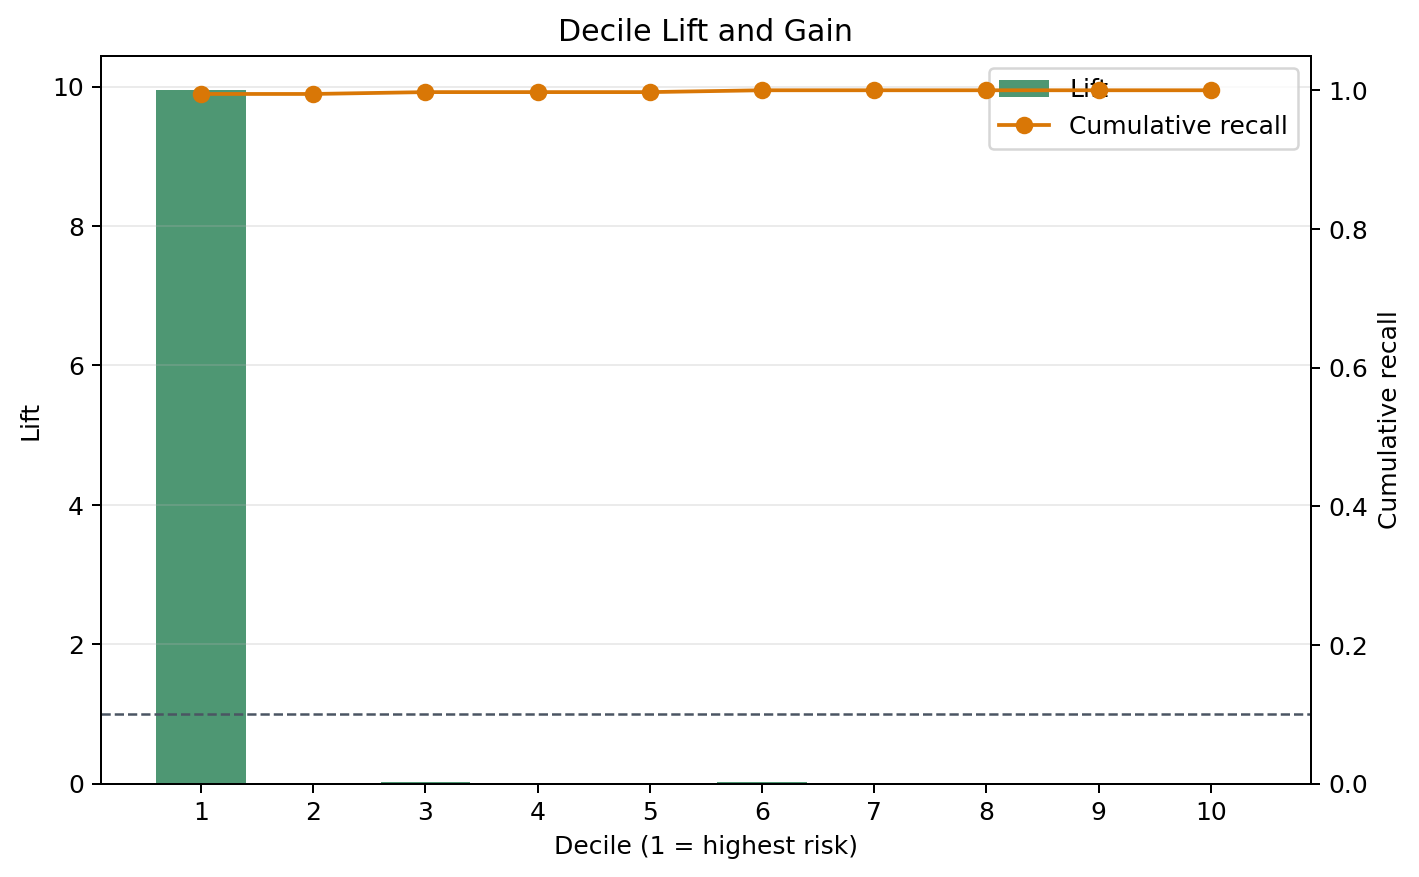

In [6]:
decile_lift = pd.read_csv(FINAL_TABLE_DIR / 'final_decile_lift_gain_summary.csv')
display(decile_lift)
display(Image(filename=str(FINAL_FIGURE_DIR / 'final_decile_lift_gain.png')))

结果显示：最高风险 decile 正类率为 23.31%，overall 正类率为 2.34%，lift=`9.95`。这说明模型排序具有业务优先级价值。

## 6. 阈值敏感性：FN 与维修工作量的取舍

阈值不是单纯技术参数，而是维修资源和漏报风险之间的业务策略选择。

,policy_rule,threshold,predicted_positive_count,workload_rate,fp,fn,precision,recall,f2,total_cost,note
0,final_threshold_018,0.18,761.0,0.047563,398.0,12.0,0.477004,0.968000,0.802742,9980.0,Current Day14 final threshold. Sensitivity tab...
1,min_cost_threshold,0.07,1016.0,0.063500,647.0,6.0,0.363189,0.984000,0.733307,9470.0,Minimum total cost in the threshold sensitivit...
2,min_cost_with_recall_ge_096,0.07,1016.0,0.063500,647.0,6.0,0.363189,0.984000,0.733307,9470.0,Minimum cost while keeping recall >= 0.96.
3,min_cost_with_recall_ge_097,0.07,1016.0,0.063500,647.0,6.0,0.363189,0.984000,0.733307,9470.0,Minimum cost while keeping recall >= 0.97.
4,min_cost_with_fn_le_15,0.07,1016.0,0.063500,647.0,6.0,0.363189,0.984000,0.733307,9470.0,Minimum cost while keeping FN <= 15.
5,min_cost_with_fn_le_12,0.07,1016.0,0.063500,647.0,6.0,0.363189,0.984000,0.733307,9470.0,"Minimum cost while keeping FN <= 12, if feasible."
6,min_workload_under_cost_near_final,0.22,703.0,0.043937,341.0,13.0,0.514936,0.965333,0.821607,9910.0,Lowest workload among thresholds with total co...


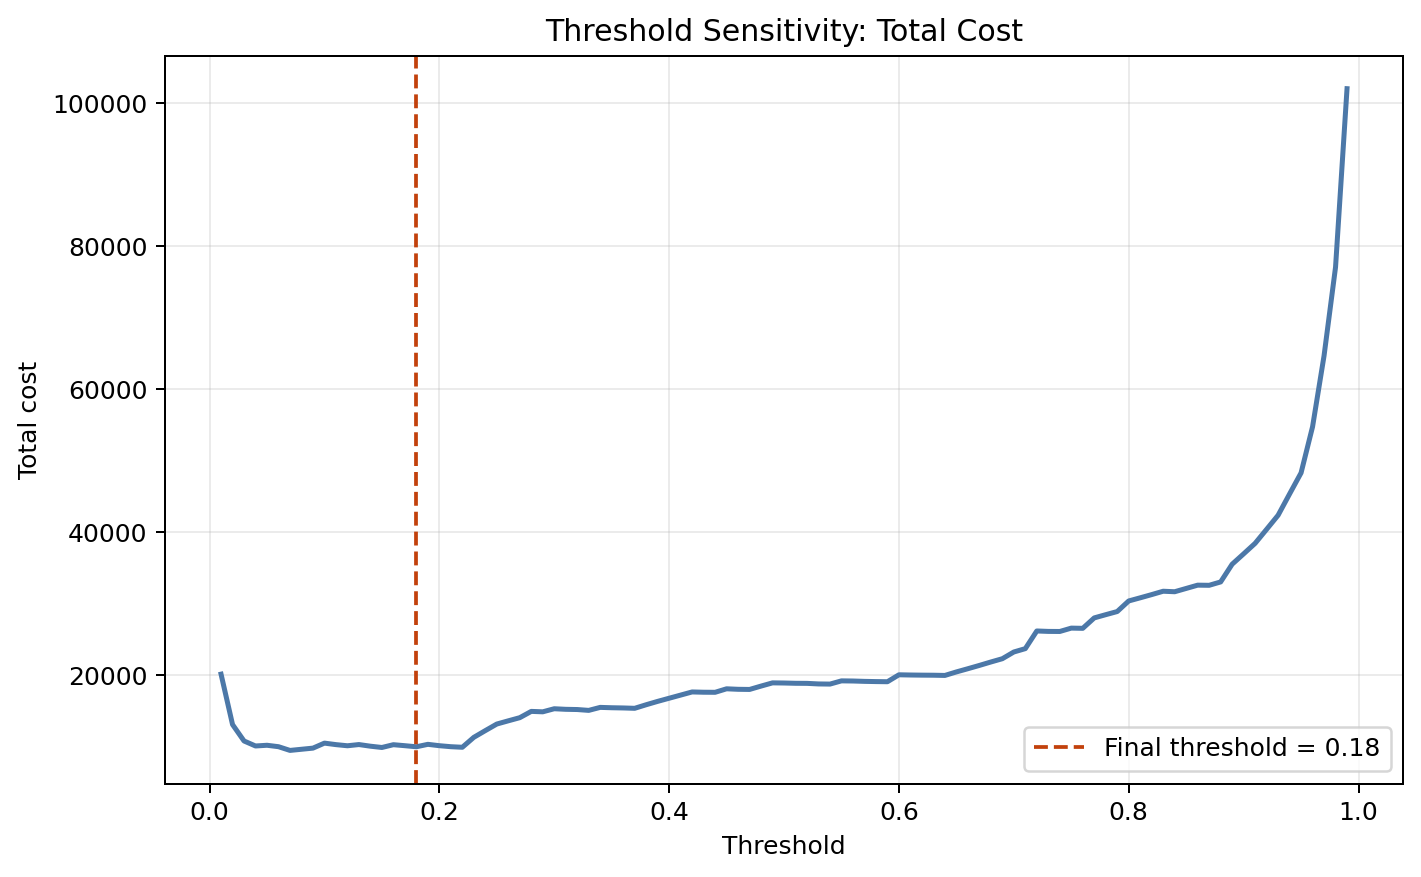

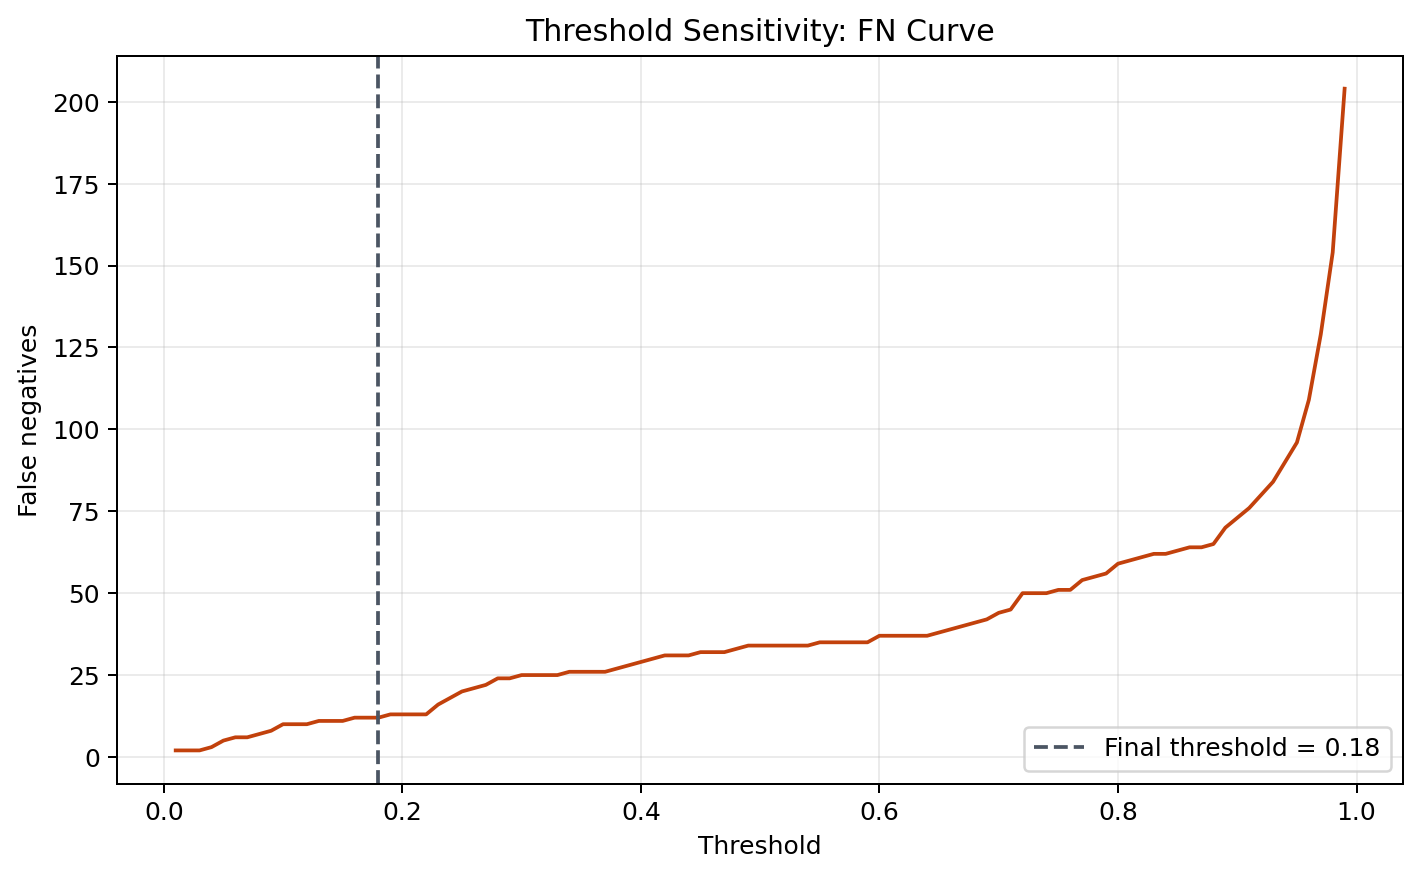

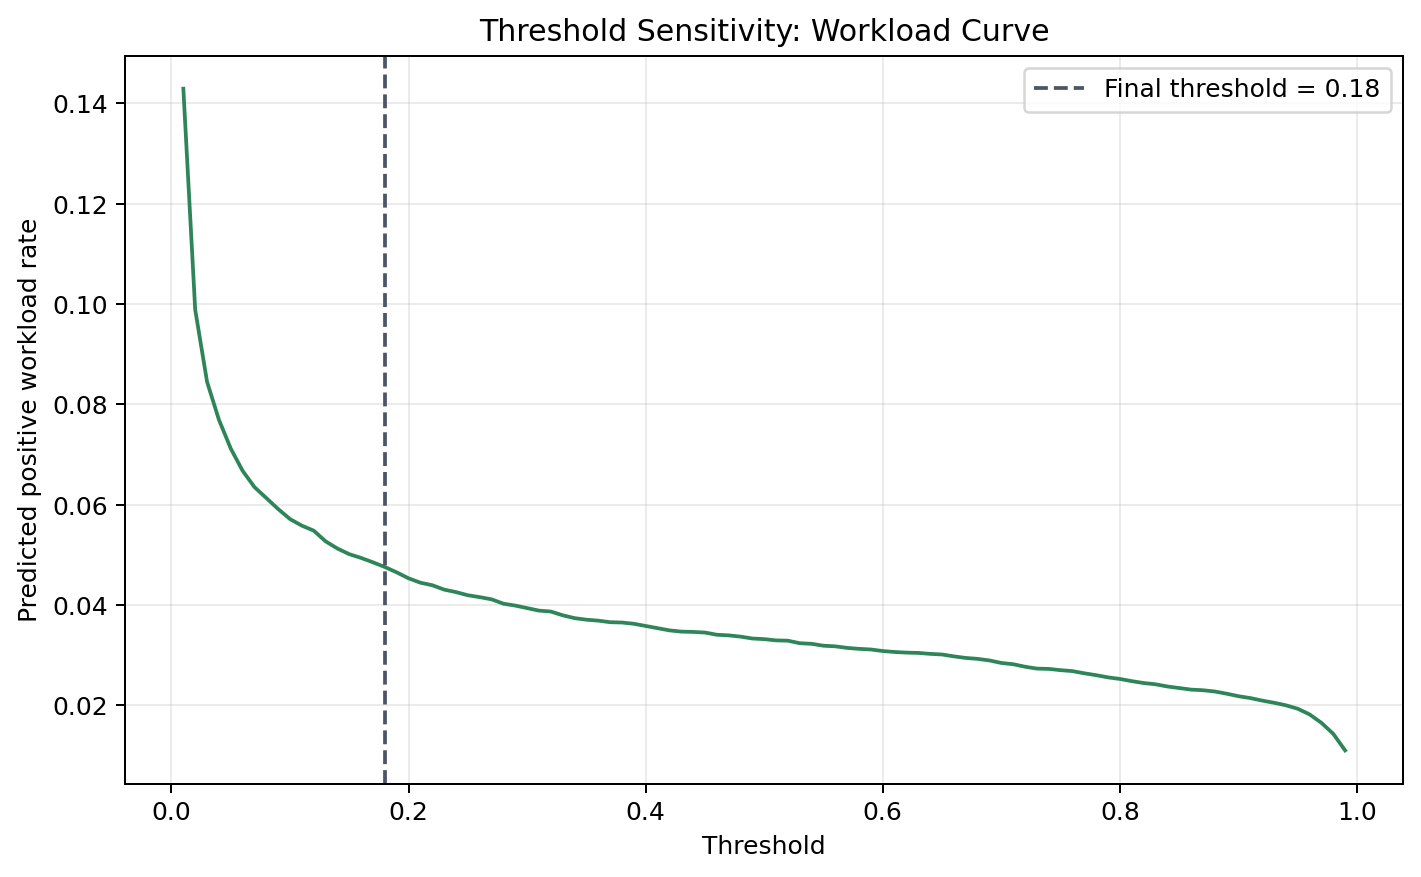

In [7]:
threshold_summary = pd.read_csv(FINAL_TABLE_DIR / 'final_threshold_sensitivity_summary.csv')
threshold_highlights = pd.read_csv(FINAL_TABLE_DIR / 'final_threshold_policy_highlights.csv')
display(threshold_highlights)
display(Image(filename=str(FINAL_FIGURE_DIR / 'final_threshold_sensitivity.png')))
display(Image(filename=str(FINAL_FIGURE_DIR / 'final_threshold_fn_curve.png')))
display(Image(filename=str(FINAL_FIGURE_DIR / 'final_threshold_workload_curve.png')))

结果显示：最终报告阈值保持 `0.18`；threshold=`0.07` 可将 FN 从 `12` 降至 `6`，但预测正类工作量从 `761` 增加到 `1016`。该分析用于业务讨论，不改变 final candidate。

## 7. FP / FN 错误分析

错误分析用于定位后续解释性分析重点：FN 和高置信 FP

,analysis_section,confusion_type,risk_level,probability_band,sample_count,avg_probability,total_sample_cost
0,confusion_type_by_probability_band,TP,NaN,"[0.10,0.20)",1,0.186372,0
1,confusion_type_by_probability_band,TP,NaN,"[0.20,0.40)",16,0.280573,0
2,confusion_type_by_probability_band,TP,NaN,"[0.40,0.60)",8,0.496325,0
3,confusion_type_by_probability_band,TP,NaN,"[0.60,0.80)",22,0.726346,0
4,confusion_type_by_probability_band,TP,NaN,"[0.80,1.00]",316,0.978628,0
5,confusion_type_by_probability_band,FP,NaN,"[0.10,0.20)",35,0.190743,350
6,confusion_type_by_probability_band,FP,NaN,"[0.20,0.40)",136,0.283220,1360
7,confusion_type_by_probability_band,FP,NaN,"[0.40,0.60)",72,0.493737,720
8,confusion_type_by_probability_band,FP,NaN,"[0.60,0.80)",67,0.708565,670
9,confusion_type_by_probability_band,FP,NaN,"[0.80,1.00]",88,0.904003,880


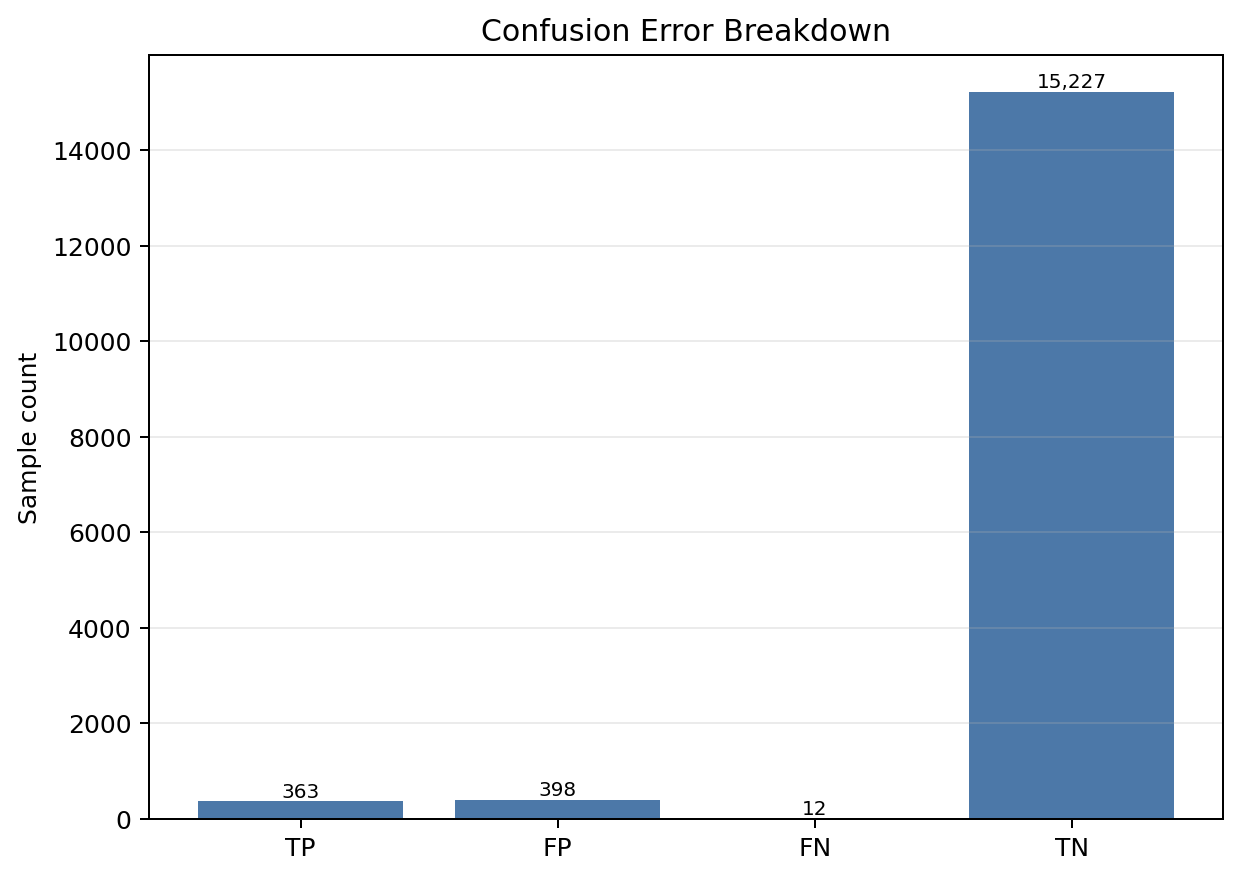

In [8]:
error_breakdown = pd.read_csv(FINAL_TABLE_DIR / 'final_error_breakdown_summary.csv')
display(error_breakdown.head(20))
display(Image(filename=str(FINAL_FIGURE_DIR / 'final_confusion_error_breakdown.png')))

## 小结

- Top-K 分析把模型排序转化为维修容量规划，Top 500 覆盖 340 / 375 个真实 APS 故障。
- 风险等级分析把概率转化为可执行的检修队列，Critical 层级真实正类率为 78.22%。
- Decile / Lift 证明最高风险分位显著富集故障样本，decile=1 lift 约 `9.95`。
- 阈值敏感性展示 FN 与维修工作量之间的业务取舍，final threshold 仍为 `0.18`。